In [6]:

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from tensorflow.keras.models import Sequential #This is used to build a layer by layer in keras
from tensorflow.keras.layers import Dense #For final predition
from tensorflow.keras.layers import Conv2D # Extracts features from image
from tensorflow.keras.layers import Flatten #Used for reshape
from tensorflow.keras.layers import MaxPooling2D #Reduce the size
from tensorflow.keras.layers import Dropout #It prevents overfitting
from tensorflow.keras.utils import to_categorical

In [57]:
df=pd.read_csv("mnist_train.csv",header=None)
df_test=pd.read_csv("mnist_test.csv")

In [58]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


in above data set 0 in first row means hand written 0 and then next all rows are the pixcel of that image 0

In [59]:
df.shape

(60000, 785)

In [10]:
df.columns

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       775, 776, 777, 778, 779, 780, 781, 782, 783, 784],
      dtype='int64', length=785)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, 0 to 784
dtypes: int64(785)
memory usage: 359.3 MB


In [12]:
df.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
...,...
780,0
781,0
782,0
783,0


In [60]:
#preprocess the data
# Training data
X_train = df.iloc[:, 1:].values.astype('float32') / 255.0
y_train = df.iloc[:, 0].values

# Test data (assuming column 0 is the label)
X_test = df_test.iloc[:, 1:].values.astype('float32') / 255.0
y_test = df_test.iloc[:, 0].values


In [ ]:
#Perceptron

In [72]:

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.utils import to_categorical

# 1. Prepare Data from df (mnist_train.csv)
X = df.iloc[:, 1:].values.astype('float32') / 255.0
y = df.iloc[:, 0].values

# Split into 80% training and 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Reshape flattened 784 pixels to 28x28 images
X_train_img = X_train.reshape(-1, 28, 28)
X_val_img = X_val.reshape(-1, 28, 28)

# One-hot encode digit labels (0-9)
y_train_cat = to_categorical(y_train, num_classes=10)
y_val_cat = to_categorical(y_val, num_classes=10)

# 2. Define the Perceptron Architecture
perceptron = Sequential([
    Flatten(input_shape=(28, 28)),          # Flattens 28x28 back to 784 inputs
    Dense(10, activation='softmax')         # 10 output classes for digits 0-9
])

# 3. Compile the Model
perceptron.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Train the Model
history_percp = perceptron.fit(
    X_train_img,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_img, y_val_cat),
    verbose=1
)

# 5. Evaluate and Print Real Accuracy
loss, accuracy = perceptron.evaluate(X_val_img, y_val_cat, verbose=0)
print(f"\nFinal Validation Accuracy: {accuracy * 100:.2f}%")


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8004 - loss: 0.8447 - val_accuracy: 0.8649 - val_loss: 0.5421
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8760 - loss: 0.4839 - val_accuracy: 0.8804 - val_loss: 0.4476
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8875 - loss: 0.4231 - val_accuracy: 0.8909 - val_loss: 0.4085
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8937 - loss: 0.3930 - val_accuracy: 0.8966 - val_loss: 0.3859
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8978 - loss: 0.3741 - val_accuracy: 0.8989 - val_loss: 0.3712
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9004 - loss: 0.3607 - val_accuracy: 0.9011 - val_loss: 0.3599
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9026 - loss: 0.3506 - val_accuracy: 0.9018 - val_loss: 0.3515
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9050 - loss: 0.3426 - 

In [71]:
#By reshape the each column convert into 28 *28 sized matrix

In [73]:
#ANN

In [74]:
ann=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
]
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [75]:
ann.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [76]:
history_ann=ann.fit(X_train_img,y_train_cat,epochs=10,batch_size=32,validation_data=(X_val_img,y_val_cat),verbose=1)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9169 - loss: 0.2743 - val_accuracy: 0.9566 - val_loss: 0.1500
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9647 - loss: 0.1153 - val_accuracy: 0.9622 - val_loss: 0.1266
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9763 - loss: 0.0779 - val_accuracy: 0.9701 - val_loss: 0.0953
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9819 - loss: 0.0583 - val_accuracy: 0.9701 - val_loss: 0.0967
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9846 - loss: 0.0460 - val_accuracy: 0.9699 - val_loss: 0.1011
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9883 - loss: 0.0368 - val_accuracy: 0.9714 - val_loss: 0.1056
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9900 - loss: 0.0310 - val_accuracy: 0.9743 - val_loss: 0.1003
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9910 - loss: 0.0268 - 

In [87]:
loss_ann,acc_ann=ann.evaluate(X_val_img,y_val_cat,verbose=0)
print(f"\nFinal Validation Accuracy: {acc_ann * 100:.2f}%")


Final Validation Accuracy: 97.39%


In [80]:
X_train_cnn=X_train.reshape(-1,28,28,1) #1 means no of layers in grey scale and in rgb 3
X_test_cnn=X_val.reshape(-1,28,28,1)

In [82]:
cnn=Sequential([
    Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,kernel_size=(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),    #Flattenn usd to convert as neural network
    Dense(128,activation='relu'),
    Dropout(0.5),  #To reduce overfiting
    Dense(10,activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [83]:
cnn.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [84]:
history_cnn=cnn.fit(X_train_cnn,y_train_cat,epochs=10,batch_size=32,validation_data=(X_test_cnn,y_val_cat),verbose=1)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.9336 - loss: 0.2176 - val_accuracy: 0.9808 - val_loss: 0.0598
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 19ms/step - accuracy: 0.9764 - loss: 0.0792 - val_accuracy: 0.9866 - val_loss: 0.0466
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9827 - loss: 0.0576 - val_accuracy: 0.9859 - val_loss: 0.0458
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9866 - loss: 0.0455 - val_accuracy: 0.9898 - val_loss: 0.0339
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.9880 - loss: 0.0385 - val_accuracy: 0.9900 - val_loss: 0.0360
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.9899 - loss: 0.0333 - val_accuracy: 0.9880 - val_loss: 0.0469
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.9900 - loss: 0.0300 - val_accuracy: 0.9893 - val_loss: 0.0397
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9923 -

In [89]:
loss_cnn,acc_cnn=cnn.evaluate(X_test_cnn,y_val_cat,verbose=0)
print(f"\nFinal Validation Accuracy: {acc_cnn * 100:.2f}%")


Final Validation Accuracy: 98.89%


In [90]:
def plot_training(history,title):
  plt.figure(figsize=(12,4))
  plt.subplot(1,2,1)
  plt.plot(history.history['accuracy'],label='Training')
  plt.plot(history.history['val_accuracy'],label='Validation')
  plt.legend()
  plt.title(f'{title} Accuracy')

  plt.subplot(1,2,2)
  plt.plot(history.history['loss'],label='Training')
  plt.plot(history.history['val_loss'],label='Validation')
  plt.legend()
  plt.title(f'{title} Loss')
  plt.show()

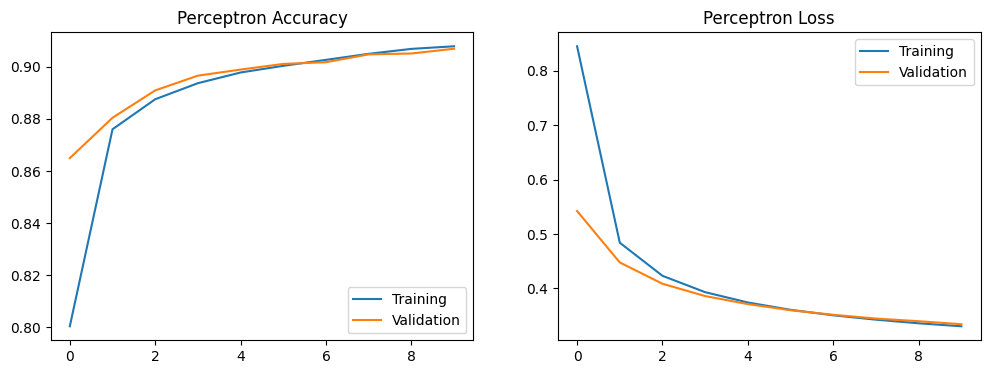

In [91]:
plot_training(history_percp,'Perceptron')   #Underfitting

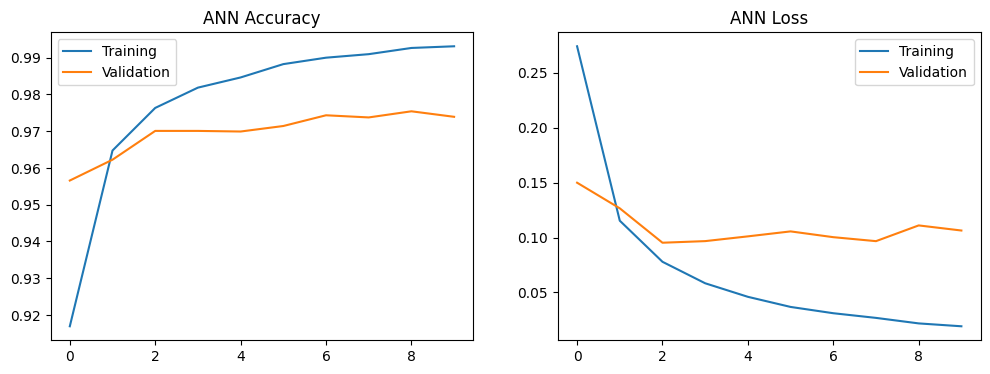

In [92]:
plot_training(history_ann,"ANN")    #Overfitting

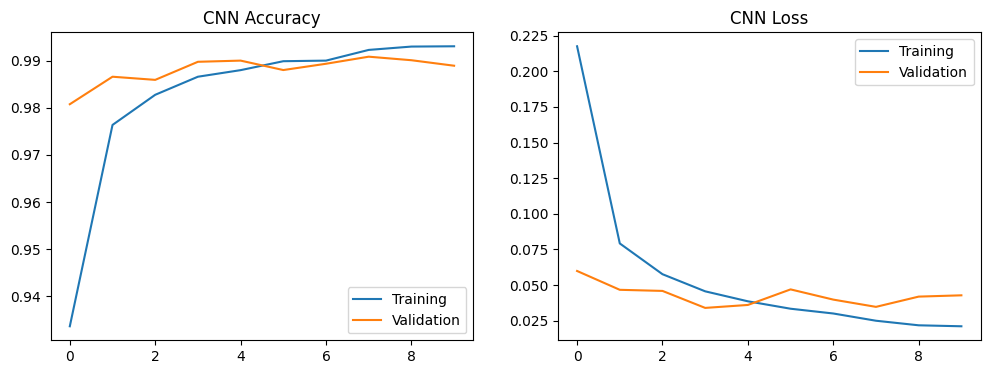

In [93]:
plot_training(history_cnn,"CNN")     #Optimal fit

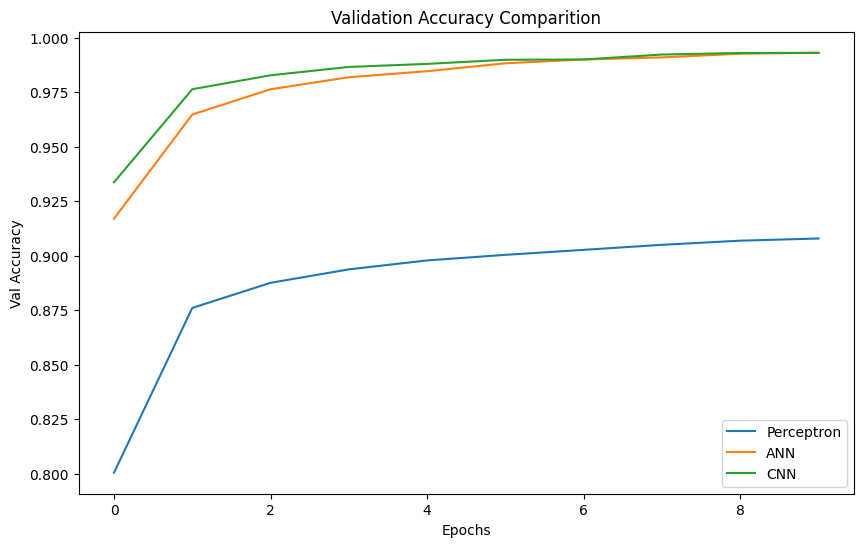

In [94]:
plt.figure(figsize=(10,6))
plt.plot(history_percp.history['accuracy'],label='Perceptron')
plt.plot(history_ann.history['accuracy'],label='ANN')
plt.plot(history_cnn.history['accuracy'],label='CNN')
plt.title("Validation Accuracy Comparition")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

In [107]:
from re import VERBOSE
def show_side_by_side(models,model_names,X,X_cnn,y_true,n=5):
  idxs=np.random.choice(len(X),n,replace=False)
  plt.figure(figsize=(12,6))
  for i,idx in enumerate(idxs):
    plt.subplot(2,n,i+1)
    plt.imshow(X[idx].reshape(28,28),cmap='gray')
    plt.title(f"True: {y_true[idx]}")
    plt.axis('off')
    preds=[np.argmax(model.predict(X_cnn[idx].reshape(1,28,28,1) if
                                   name=="CNN" else X[idx].reshape(1,28,28),verbose=0))
    for model,name in zip(models,model_names)]
    plt.subplot(2,n,n+i+1)
    plt.axis("off")
    plt.text(0.5,0.5,"\n".join(f"{n}: {p}" for n,p in zip(model_names,preds)))
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

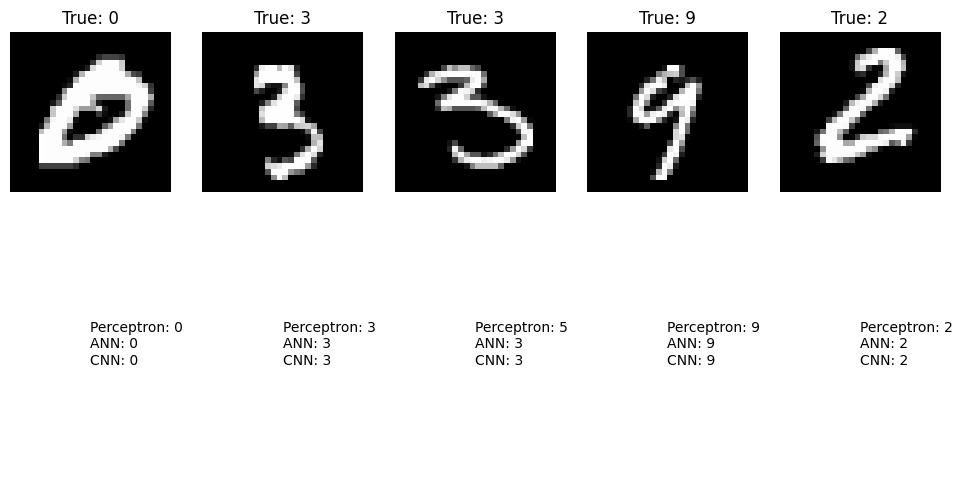

In [115]:
show_side_by_side([perceptron,ann,cnn],["Perceptron","ANN","CNN"], X_val_img,X_test_cnn,y_val,5)

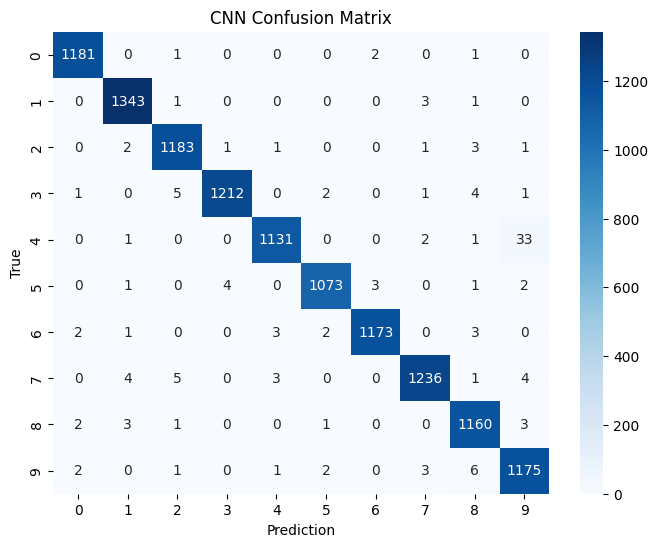

In [118]:
y_pred_cnn=np.argmax(cnn.predict(X_test_cnn,verbose=0),axis=1)
cm=confusion_matrix(y_val,y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("True")
plt.show()

In [119]:
#WHat we can observe here is 4 is predicted as 9 33 times , 7 is predicted as 2 5 times

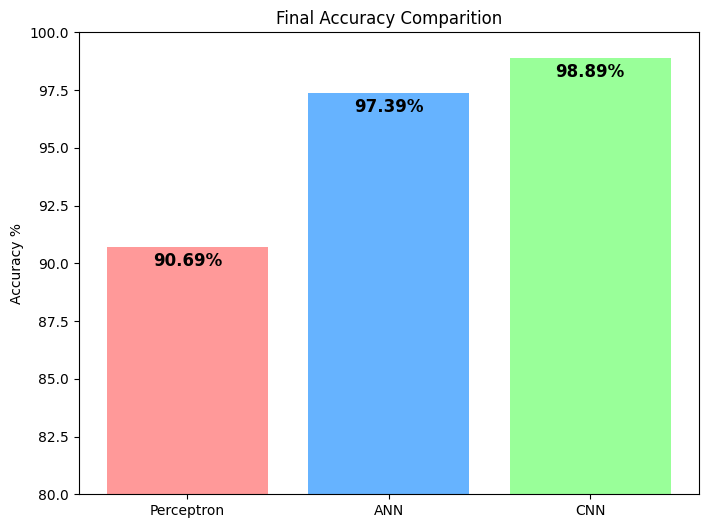

In [120]:
final_accs=[accuracy*100,acc_ann*100,acc_cnn*100]
models=["Perceptron","ANN","CNN"]

plt.figure(figsize=(8,6))
bars=plt.bar(models,final_accs,color=['#ff9999','#66b3ff','#99ff99'])
plt.ylabel("Accuracy %")
plt.title("Final Accuracy Comparition")
for bar,acc in zip(bars,final_accs):

  plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()-1,f"{acc:.2f}%",ha='center',va='bottom',fontsize=12,fontweight='bold')
plt.ylim(80,100)
plt.show()
